In [98]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import plotly.graph_objects as go

from rod.helix import Helix
from rod.helix_util import HelixUtil

In [99]:
# Methods to propagate the centerline and material frames of a helix

def propagate_q(q: np.ndarray, r0: np.ndarray, n0: np.ndarray, n_sites: int, s: np.ndarray, r: np.ndarray,
                    n: np.ndarray):
        # Starting with the clamped material frame, integrate forward
        r[0, :] = r0
        n[0, :] = n0
        for i in range(1, n_sites):
            # Left hand side of interval (previous element)
            r_L = r[i - 1]
            n_L = n[i - 1]
            s_R, s_L = s[i], s[i - 1]
            s_sL = s_R - s_L
            # Twist and curvature
            tau, k_1, k_2 = q[3 * i - 3:3 * i]
            # Darboux vector and unit vector aligned with the Darboux vector
            Omega = tau * n_L[0, :] + k_1 * n_L[1, :] + k_2 * n_L[2, :]
            Omega_norm = np.linalg.norm(Omega)

            # Degenerate case: straight line/no change in material frame
            if Omega_norm < 1e-12:
                n[i] = n_L
                r[i] = r_L + n_L[0] * s_sL
                continue

            w = Omega / Omega_norm

            # Projection of vector parallel to and perpendicular to w
            n_L_par = np.dot(n_L, w)[:, np.newaxis] * w
            n_L_perp = n_L - n_L_par

            # Compute the material frame
            n_i = n_L_par + n_L_perp * np.cos(Omega_norm * s_sL) + np.cross(w, n_L_perp) * np.sin(Omega_norm * s_sL)
            n[i] = n_i

            # Compute the centerline
            n_0_parallel = n_L_par[0]
            n_0_perp = n_L_perp[0]
            r_i = (r_L + n_0_parallel * s_sL + n_0_perp * np.sin(Omega_norm * s_sL) / Omega_norm +
                   np.cross(w, n_0_perp) * (1 - np.cos(Omega_norm * s_sL)) / Omega_norm)
            r[i] = r_i
        return r, n

def propagate(helix: Helix) -> tuple[np.ndarray, np.ndarray]:
    """
    Computes the centerline and the material frames from the generalized coordinates [q]

    n_i(s) = n_{i, L}^{Q ||} + n_{i, L}^{Q perp} cos(Omega(s - s_L^Q)) + omega \cross n_{i, L}^{Q perp} sin(Omega(s - s_L^Q))
    """
    # Centerline and material frames
    r = np.zeros((helix.n_sites, 3))
    n = np.zeros((helix.n_sites, 3, 3))
    HelixUtil.propagate_q(helix.q, helix.r0, helix.n0, helix.n_sites, helix.s, r, n)
    return r, n

In [100]:
def plot_helix(r: np.ndarray, n: np.ndarray, ax=None, show_frames=True, frame_step=2, frame_scale=0.02):
    """
    Visualizes the helix centerline and material frames with smaller frames.

    Parameters:
    - r: (n_sites, 3) Centerline positions
    - n: (n_sites, 3, 3) Material frames
    - show_frames: Whether to show material frames
    - frame_step: Step size for plotting frames (to avoid clutter)
    - frame_scale: Scaling factor for material frame vectors
    """
    if ax is None:
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111, projection='3d')

    # Plot centerline
    ax.plot(r[:, 0], r[:, 1], r[:, 2], 'b-', label="Centerline")

    if show_frames:
        for i in range(0, len(r), frame_step):
            origin = r[i]
            for j, color in enumerate(['r', 'g', 'k']):  # x (red), y (green), z (black)
                frame_vec = n[i, j] * frame_scale  # Scale frame vectors
                ax.quiver(origin[0], origin[1], origin[2], 
                          frame_vec[0], frame_vec[1], frame_vec[2], 
                          color=color, alpha=0.8)
    ax.set_xticks(np.linspace(np.min(r[:, 0]), np.max(r[:, 0]), num=5))  # Adjust for desired number of ticks
    ax.set_yticks(np.linspace(np.min(r[:, 1]), np.max(r[:, 1]), num=5))
    ax.set_zticks(np.linspace(np.min(r[:, 2]), np.max(r[:, 2]), num=5))

    # Fix axis scale to be the same
    ax.set_box_aspect([1, 1, 1])  # Ensure equal scaling for all axes

    # Optionally set labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    # ax.set_title('Helix')

    return ax

    # # Labels and view adjustments
    # # ax.set_xlabel('X')
    # # ax.set_ylabel('Y')
    # # ax.set_zlabel('Z')
    # # ax.set_title('Helix')
    # ax.set_xticks([])
    # ax.set_yticks([])
    # ax.set_zticks([])

    # return ax 

def plot_helix_plotly(helices, show_frames=True, frame_step=2, frame_scale=0.02):
    """
    Creates an interactive visualization of multiple helices' centerlines and material frames.

    Parameters:
    - helices: Array-like of tuples (r, n), where:
      - r: (n_sites, 3) Centerline positions
      - n: (n_sites, 3, 3) Material frames
    - show_frames: Whether to show material frames
    - frame_step: Step size for plotting frames (to avoid clutter)
    - frame_scale: Scaling factor for material frame vectors
    """
    # Create figure
    fig = go.Figure()

    # Plot each helix
    for idx, (r, n) in enumerate(helices):
        # Plot centerline
        fig.add_trace(go.Scatter3d(
            x=r[:, 0], y=r[:, 1], z=r[:, 2],
            mode='lines',
            line=dict(width=3),
            name=f'Centerline {idx + 1}'
        ))

        # Plot material frames as arrows
        if show_frames:
            for i in range(0, len(r), frame_step):
                origin = r[i]
                for j, color in enumerate(['red', 'green', 'black']):  # x (red), y (green), z (black)
                    frame_vec = n[i, j] * frame_scale  # Scale frame vectors
                    fig.add_trace(go.Scatter3d(
                        x=[origin[0], origin[0] + frame_vec[0]],
                        y=[origin[1], origin[1] + frame_vec[1]],
                        z=[origin[2], origin[2] + frame_vec[2]],
                        mode='lines',
                        line=dict(color=color, width=2),
                        showlegend=False  # Avoid excessive legend entries
                    ))

    # Update layout
    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
        ),
        title=dict(text='Helix Visualization', y=0.95, x=0.5, xanchor='center', yanchor='top'),
    )

    fig.show()


def plot_just_helices(helices, show_frames=True, frame_step=2, frame_scale=0.02):
    # Create figure
    fig = go.Figure()

    # Plot each helix
    for idx, r in enumerate(helices):
        # Plot centerline
        fig.add_trace(go.Scatter3d(
            x=r[:, 0], y=r[:, 1], z=r[:, 2],
            mode='lines',
            line=dict(width=3),
            name=f'Centerline {idx + 1}'
        ))

    # Update layout
    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
        ),
        title=dict(text='Helix Visualization', y=0.95, x=0.5, xanchor='center', yanchor='top'),
    )

    fig.show()

(200, 3)


<Axes3DSubplot:xlabel='X', ylabel='Y'>

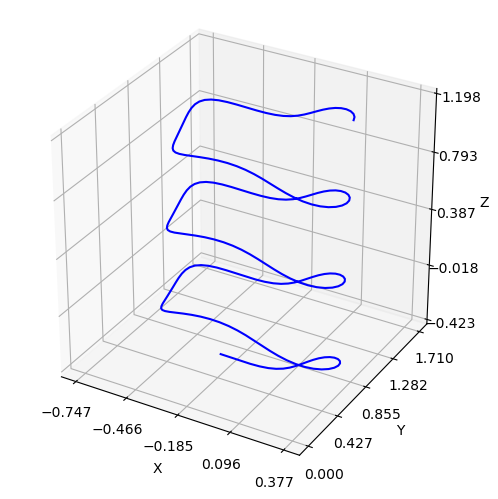

In [101]:
n_sites = 200  # Number of sites along the helix
L = 10.0  # Total length
s = np.linspace(0, L, n_sites)  # Arc length array

# Initial position: Start the curl at the origin
r0 = np.array([0.0, 0.0, 0.0])

# Initial material frame: Oriented along the curl
n0 = np.eye(3)  # Standard basis (modify if needed)

# Create a twisting and bending motion in q
twist = np.full(n_sites, np.pi)
# twist = np.zeros(n_sites)
curvature_x = 3.0 * np.cos(s * np.pi) #+ np.random.random_sample() # Varies to form a curl
curvature_y = 3.0 * np.cos(s * np.pi) #3.0 * np.sin(s * np.pi) + np.random.random_sample()  # Varies to form a curl

q = np.zeros((3 * n_sites,))
q[0::3] = twist
q[1::3] = curvature_x
q[2::3] = curvature_y

# Define stiffness (optional)
EI = np.ones((3 * n_sites,)) * 0.1  # Uniform stiffness

# Create helix instance
# r0 and n0 are the position and material frame of the clamped top node
helix_instance = Helix(q=q, q0=q, n_sites=n_sites, s=s, L=L, r0=r0, n0=n0, EI=EI)

# Generate and propagate a helix (from previous code)
r, n = HelixUtil.propagate(helix_instance)
print(r.shape)

# Plot the helix with small material frames
plot_helix_plotly([(r, n)], frame_scale=0.2, show_frames=False)
plot_helix(r, n, show_frames=False, frame_scale=0.2)

In [102]:
import numpy as np
from scipy.interpolate import interp1d

group_size = 61
real_centerline = np.zeros_like(r[:-group_size, :])
# average positions considering group size of 5
for i in range(group_size):
    real_centerline += r[i:-group_size+i, :]
real_centerline /= group_size

real_centerline = np.concatenate((r[0:1, :], real_centerline, r[-1:, :]), axis=0) # adding top clamped point

#redistributing points along centerline to be uniformly spaced
distances = np.cumsum(np.linalg.norm(np.diff(real_centerline, axis=0), axis=1))
distances = np.insert(distances, 0, 0)

n_new = len(r)  # Same # points as helix
new_distances = np.linspace(0, distances[-1], n_new)
interp_func = interp1d(distances, real_centerline, axis=0, kind='linear')  # Linear interpolation
real_centerline = interp_func(new_distances)

print(len(r))
print(len(real_centerline))
deltas_vec = r - real_centerline
n_fake = np.zeros_like(n)

curl = r
helices = [(r,n), (real_centerline, n_fake)]
fig = go.Figure()

# Plot each helix
for idx, (r, n) in enumerate(helices):
    # Plot centerline
    fig.add_trace(go.Scatter3d(
        x=r[:, 0], y=r[:, 1], z=r[:, 2],
        mode='lines',
        line=dict(width=3),
        name=f'Centerline {idx + 1}'
    ))

# plot difference vectors
for i in range(len(curl)):
    fig.add_trace(go.Scatter3d(
        x=[curl[i, 0], real_centerline[i, 0]], 
        y=[curl[i, 1], real_centerline[i, 1]],
        z=[curl[i, 2], real_centerline[i, 2]],
        mode='lines',  # Plot each vector as a line
        line=dict(color='red', width=2),  # Red color for the lines
        showlegend=True  # Avoid cluttering the legend
    ))

# Update layout
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
    ),
    title=dict(text='Helix Visualization with Difference Vectors', y=0.95, x=0.5, xanchor='center', yanchor='top'),
)

fig.show()


200
200


In [103]:
# Creating toy target centerline from another curl
n_sites = 200  # Number of sites along the helix
L = 10.0  # Total length
s = np.linspace(0, L, n_sites)
r0 = np.array([0.0, 0.0, 0.0])
n0 = np.eye(3)  # Standard basis (modify if needed)
twist = 0 #np.full(n_sites, np.pi / 4)
curvature_x = 0 #1.0 * np.cos(s * np.pi / 6) + np.random.random_sample() # Varies to form a curl
curvature_y = 0 #3.0 * np.sin(s * np.pi) + np.random.random_sample()  # Varies to form a curl
q = np.zeros((3 * n_sites,))
q[0::3] = twist
q[1::3] = curvature_x
q[2::3] = curvature_y
EI = np.ones((3 * n_sites,)) * 0.1  # Uniform stiffness
helix_instance = Helix(q=q, q0=q, n_sites=n_sites, s=s, L=L, r0=r0, n0=n0, EI=EI)
r, n = HelixUtil.propagate(helix_instance)
print(r.shape)

(200, 3)


In [104]:
# I know I am simulating all of my original curls with L = 10, n_sites = 200
# Finding the scaling of the target centerline --> sampling it to match our simulated curl node # (which must be high enough already)
target_centerline = r
node_diff = target_centerline.shape[0] - deltas_vec.shape[0]

if node_diff != 0: # always resample target_centerline to have same # nodes as deltas_vec
    distances = np.cumsum(np.linalg.norm(np.diff(target_centerline, axis=0), axis=1))
    distances = np.insert(distances, 0, 0)

    n_new = len(deltas_vec)  # Same # points as helix
    new_distances = np.linspace(0, distances[-1], n_new)
    interp_func = interp1d(distances, target_centerline, axis=0, kind='linear')  # Linear interpolation
    target_centerline = interp_func(new_distances)

diff = np.diff(target_centerline, axis=0) 
distances = np.linalg.norm(diff, axis=1)
arc_length_target = np.sum(distances)
print(arc_length_target)
arc_length_original = 10
scaling_factor = (arc_length_target / arc_length_original)
print(scaling_factor)

# Normalizing target centerline to have n_sites, finding scaling factor to L arc_length of original curl
new_curl = target_centerline + deltas_vec * scaling_factor

fig = go.Figure()

# Plot each helix
fig.add_trace(go.Scatter3d(
    x=target_centerline[:, 0], y=target_centerline[:, 1], z=target_centerline[:, 2],
    mode='lines',
    line=dict(color='red', width=3),
    name=f'Target Centerline',
    showlegend=True 
))

fig.add_trace(go.Scatter3d(
    x=new_curl[:, 0], y=new_curl[:, 1], z=new_curl[:, 2],
    mode='lines',
    line=dict(color='blue', width=3),
    name=f'New Curl',
    showlegend=True 
))

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
    ),
    title=dict(text='Curl Shape', y=0.95, x=0.5, xanchor='center', yanchor='top'),
)

fig.show()

10.0
1.0


In [107]:
import numpy as np

def create_target_centerlines(num_centerlines, n_points_list, L_list, spacing=5.0):
    target_centerlines = []
    
    for i in range(num_centerlines):
        n_sites = int(n_points_list[i])  # Number of sites along the helix
        L = int(L_list[i])  # Total length
        s = np.linspace(0, L, n_sites)
        r0 = np.array([i * spacing, 0.0, 0.0])  # Evenly spaced along x-axis
        n0 = np.eye(3)  # Standard basis
        twist = np.full(n_sites, np.pi / 12)
        curvature_x = 1.0 * np.cos(s * np.pi / 6) + np.random.random_sample()
        curvature_y = 0  # Keeping y-curvature at 0
        q = np.zeros((3 * n_sites,))
        q[0::3] = twist
        q[1::3] = curvature_x
        q[2::3] = curvature_y
        EI = np.ones((3 * n_sites,)) * 0.1  # Uniform stiffness
        
        helix_instance = Helix(q=q, q0=q, n_sites=n_sites, s=s, L=L, r0=r0, n0=n0, EI=EI)
        r, n = HelixUtil.propagate(helix_instance)
        
        # Set the top z-coordinate to 0
        r[0, 2] = 0
        target_centerlines.append(r)
    
    return target_centerlines

n_points_list = np.linspace(200, 200, 200)
L_list = np.linspace(5, 50, 4)
target_centerlines = create_target_centerlines(4, n_points_list, L_list)

new_curls = []
for i in range(len(target_centerlines)):
    node_diff = target_centerlines[i].shape[0] - deltas_vec.shape[0]

    if node_diff != 0: # always resample target_centerline to have same # nodes as deltas_vec
        distances = np.cumsum(np.linalg.norm(np.diff(target_centerlines[i], axis=0), axis=1))
        distances = np.insert(distances, 0, 0)

        n_new = len(deltas_vec)  # Same # points as helix
        new_distances = np.linspace(0, distances[-1], n_new)
        interp_func = interp1d(distances, target_centerlines[i], axis=0, kind='linear')  # Linear interpolation
        target_centerlines[i] = interp_func(new_distances)

    diff = np.diff(target_centerlines[i], axis=0) 
    distances = np.linalg.norm(diff, axis=1)
    arc_length_target = np.sum(distances)
    arc_length_original = 10
    scaling_factor = (arc_length_target / arc_length_original)

    # Normalizing target centerline to have n_sites, finding scaling factor to L arc_length of original curl
    new_curl = target_centerlines[i] + deltas_vec * scaling_factor
    new_curls.append(new_curl)

# plot_just_helices(np.vstack((target_centerlines, new_curls)), show_frames=False)
plot_just_helices([new_curls[0]] + [target_centerlines[0]])
plot_just_helices([target_centerlines[0]])


In [106]:
def plot_just_helices(helices, show_frames=True, frame_step=2, frame_scale=0.02):
    # Create figure
    fig = go.Figure()

    # Plot each helix
    for idx, r in enumerate(helices):
        # Plot centerline
        fig.add_trace(go.Scatter3d(
            x=r[:, 0], y=r[:, 1], z=r[:, 2],
            mode='lines',
            line=dict(width=3),
            name=f'Centerline {idx + 1}'
        ))

    # Update layout
    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
        ),
        title=dict(text='Helix Visualization', y=0.95, x=0.5, xanchor='center', yanchor='top'),
    )

    fig.show()

target_centerlines = create_target_centerlines(3, [15, 10, 15], [15, 10, 5])

def compute_L(r):
    diff = np.diff(r, axis=0) 
    distances = np.linalg.norm(diff, axis=1)
    arc_length = np.sum(distances)
    return arc_length

def create_curls(L_list, site_list, curl_amount):
    pos = []
    for i in range(len(L_list)):
        n_sites = site_list[i]  # Number of sites along the helix
        L = L_list[i] # Total length
        s = np.linspace(0, L, n_sites)  # Arc length array
        r0 = np.array([0.0, 0.0, 0.0])
        n0 = np.eye(3)  # Standard basis (modify if needed)

        twist = np.full(n_sites, np.pi)
        curvature_x = curl_amount * np.cos(s * np.pi) + np.random.random_sample() # Varies to form a curl
        curvature_y = 0 #3.0 * np.sin(s * np.pi) + np.random.random_sample()  # Varies to form a curl

        q = np.zeros((3 * n_sites,))
        q[0::3] = twist
        q[1::3] = curvature_x
        q[2::3] = curvature_y

        EI = np.ones((3 * n_sites,)) * 0.1  # Uniform stiffness

        # r0 and n0 are the position and material frame of the clamped top node
        helix_instance = Helix(q=q, q0=q, n_sites=n_sites, s=s, L=L, r0=r0, n0=n0, EI=EI)

        r, _ = HelixUtil.propagate(helix_instance)
        pos.append(r)
    return pos

def compute_centerlines(r_list, group_size):
    real_centerlines = []
    for r in r_list:
        real_centerline = np.zeros_like(r[:-group_size, :])
        
        # moving average of positions
        for i in range(group_size):
            real_centerline += r[i:-group_size+i, :]
        real_centerline /= group_size

        real_centerline = np.concatenate((r[0:1, :], real_centerline, r[-1:, :]), axis=0) # adding top/bottom clamped point

        #redistributing points along centerline to be uniformly spaced
        distances = np.cumsum(np.linalg.norm(np.diff(real_centerline, axis=0), axis=1))
        distances = np.insert(distances, 0, 0)

        n_new = len(r)  # Same # points as helix
        new_distances = np.linspace(0, distances[-1], n_new)
        interp_func = interp1d(distances, real_centerline, axis=0, kind='linear')  # Linear interpolation
        real_centerline = interp_func(new_distances)
        real_centerlines.append(real_centerline)
    return real_centerlines

def compute_shape(r_list, real_centerline_list):
    deltas = []
    for i in range(len(r_list)):
        deltas_vec = r_list[i] - real_centerline_list[i]
        deltas.append(deltas_vec)
    return deltas
    
def gen_new_curls(target_centerlines):
    '''
    target_centerlines: list of 
    '''
    # First, get n_sites and length of target centerlines - working ✅
    n_sites = [len(target_centerlines[i]) for i in range(len(target_centerlines))]
    L = [compute_L(target_centerlines[i]) for i in range(len(target_centerlines))]
    
    # Instantiate curls to simulate, evolve them
    simulated_curls = create_curls(L, n_sites, 8)
    # TODO: simulate under gravity (once in an actual script)
    # Compute centerlines
    real_centerlines = compute_centerlines(simulated_curls, group_size=10)
    # Compute shape deltas
    deltas = compute_shape(simulated_curls, real_centerlines)

    # Applying simulated shapes onto target centerlines
    new_curls = [target_centerlines[i] + deltas[i] for i in range(len(target_centerlines))]
    return new_curls

new_curls = gen_new_curls(target_centerlines)
print(len(new_curls))
plot_just_helices(new_curls + target_centerlines)

3
